# Credit Card Fraud Detection - Exploratory Data Analysis (EDA)

## Step 1: Define Objective

### Project Goal

The primary objective of this EDA is to systematically analyze a credit card transaction dataset and:

1. **Understand the dataset structure and quality** - Examine its dimensions, data types, completeness, and overall characteristics.
2. **Analyze fraudulent vs. legitimate transactions** - Identify patterns and differences between fraudulent (`Class = 1`) and legitimate (`Class = 0`) transactions.
3. **Examine unusual observations and outliers** - Investigate atypical transaction behavior and assess how it differs between fraudulent and legitimate transactions.
4. **Explore feature relationships and distributions** - Analyze the distributions, correlations, and behavioral patterns of the available features.
5. **Prepare data for machine learning** - Assess data quality, identify preprocessing requirements, and engineer relevant features for subsequent model development.
6. **Communicate findings through effective visualizations** - Use appropriate visualizations to support the analysis and clearly communicate evidence-based findings.

### Key Questions to Explore

- What is the distribution of fraudulent vs. legitimate transactions?
- Which features show the strongest differences between fraudulent and legitimate transactions?
- Are there temporal patterns associated with fraudulent transactions?
- How do transaction amounts differ between fraudulent and legitimate transactions?
- Are there data quality issues, such as missing values, duplicates, or inconsistent data types?
- Are there notable outliers or unusual observations within the dataset?

### Expected Outcomes

- A clear understanding of the dataset structure, quality, and characteristics
- Identification of meaningful patterns differentiating fraudulent and legitimate transactions
- Detection and assessment of relevant data quality issues and unusual observations
- Evidence-based visual insights into transaction behavior
- Engineered features suitable for subsequent machine learning workflows
- A documented foundation for developing fraud detection models

## Step 2: Load Data

In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Step 3: # Analyze target variable distribution

In [28]:
class_counts = df["Class"].value_counts()

print("Target Variable (Class) Distribution")
print("=" * 40)
print(f"Normal transactions: {class_counts[0]:,}")
print(f"Fraudulent transactions: {class_counts[1]:,}")
print(f"Fraud percentage: {df['Class'].mean() * 100:.2f}%")

Target Variable (Class) Distribution
Normal transactions: 284,315
Fraudulent transactions: 492
Fraud percentage: 0.17%


In [3]:
# Generate a comprehensive EDA report
print("Generating Sweetviz EDA report...")

report = sv.analyze(df, target_feat="Class")
report.show_html("creditcard_EDA_report.html", open_browser=True)

print("EDA report saved as 'creditcard_EDA_report.html'.")

Generating Sweetviz EDA report...


                                             |          | [  0%]   00:00 -> (? left)

Report creditcard_EDA_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
EDA report saved as 'creditcard_EDA_report.html'.


In [29]:
# Dataset overview and data quality

print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nMissing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes.value_counts())

Dataset shape: (284807, 31)
Memory usage: 67.36 MB

Missing values: 0
Duplicate rows: 1081

Data types:
float64    30
int64       1
Name: count, dtype: int64


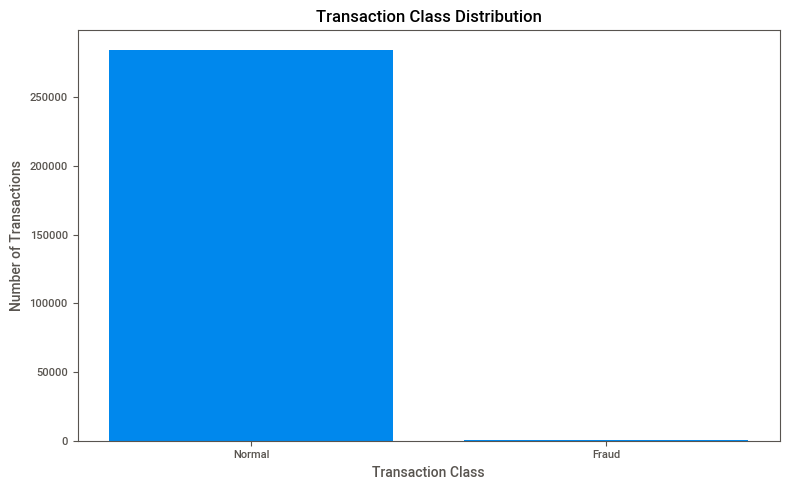

In [30]:
# Visualize transaction class distribution

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    ["Normal", "Fraud"],
    [class_counts[0], class_counts[1]]
)

ax.set_title("Transaction Class Distribution")
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## Step 4: Handle Missing/Duplicate Data - Ensure Data Integrity

Let's check for duplicates and ensure our dataset has data integrity.


In [31]:
# Check data integrity

missing_values = df.isna().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total missing values: {missing_values.sum()}")
print(f"Total duplicate rows: {duplicate_rows}")
print(f"Duplicate percentage: {duplicate_rows / len(df) * 100:.4f}%")

if missing_values.any():
    print("\nColumns with missing values:")
    print(missing_values[missing_values > 0])

if duplicate_rows:
    duplicate_data = df[df.duplicated(keep=False)]
    fraud_in_duplicates = duplicate_data["Class"].sum()

    print(f"\nRows involved in duplicates: {len(duplicate_data)}")
    print(f"Fraud cases among duplicates: {fraud_in_duplicates}")

Total missing values: 0
Total duplicate rows: 1081
Duplicate percentage: 0.3796%

Rows involved in duplicates: 1854
Fraud cases among duplicates: 32


In [32]:
# Validate key data constraints

negative_amounts = (df["Amount"] < 0).sum()
invalid_class = ~df["Class"].isin([0, 1])

print(f"Negative amounts: {negative_amounts}")
print(f"Invalid Class values: {invalid_class.sum()}")

Negative amounts: 0
Invalid Class values: 0


In [33]:
# Remove exact duplicate rows

if duplicate_rows:
    original_shape = df.shape

    df = df.drop_duplicates().copy()

    print(f"Original shape: {original_shape}")
    print(f"Cleaned shape: {df.shape}")
    print(f"Rows removed: {original_shape[0] - df.shape[0]}")

Original shape: (284807, 31)
Cleaned shape: (283726, 31)
Rows removed: 1081


In [34]:
# Final data integrity summary

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (283726, 31)
Missing values: 0
Duplicate rows: 0
Memory usage: 69.27 MB


## Step 5: Fix Inconsistencies - Clean the Dataset

Let's identify and fix any data inconsistencies to ensure our dataset is clean and ready for analysis.


In [35]:
# Check for data type inconsistencies

numeric_columns = df.columns.drop("Class")
non_numeric_columns = df[numeric_columns].select_dtypes(exclude="number").columns

print(f"Non-numeric feature columns: {len(non_numeric_columns)}")

if len(non_numeric_columns):
    print(non_numeric_columns.tolist())
else:
    print("All feature columns have numeric data types.")

Non-numeric feature columns: 0
All feature columns have numeric data types.


In [36]:
# Check for infinite values

numeric_data = df.select_dtypes(include="number")
infinite_values = np.isinf(numeric_data).sum()

infinite_columns = infinite_values[infinite_values > 0]

if infinite_columns.empty:
    print("No infinite values found.")
else:
    print("Infinite values by column:")
    print(infinite_columns)

No infinite values found.


In [37]:
# Check logical consistency of key variables

negative_time = (df["Time"] < 0).sum()
negative_amount = (df["Amount"] < 0).sum()

print(f"Negative Time values: {negative_time}")
print(f"Negative Amount values: {negative_amount}")

Negative Time values: 0
Negative Amount values: 0


In [38]:
# Final data quality verification

print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Infinite values: {np.isinf(df.select_dtypes(include='number')).sum().sum()}")
print(f"Negative amounts: {(df['Amount'] < 0).sum()}")

Missing values: 0
Duplicate rows: 0
Infinite values: 0
Negative amounts: 0


## Step 6: Univariate Analysis - Study Each Variable

Let's analyze each variable individually to understand their distributions, patterns, and characteristics.


Class Distribution:
Normal (0): 283,253 (99.83%)
Fraud (1): 473 (0.17%)


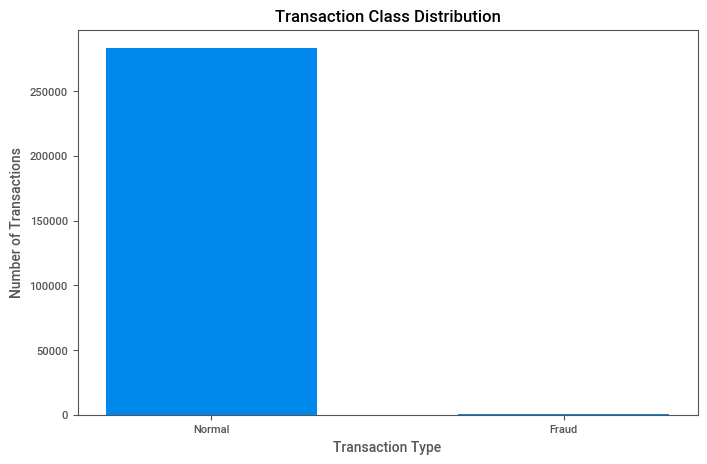

In [39]:
# Univariate analysis of the target variable

class_distribution = df["Class"].value_counts().sort_index()
class_percentage = df["Class"].value_counts(normalize=True).sort_index() * 100

print("Class Distribution:")
print(f"Normal (0): {class_distribution[0]:,} ({class_percentage[0]:.2f}%)")
print(f"Fraud (1): {class_distribution[1]:,} ({class_percentage[1]:.2f}%)")

plt.figure(figsize=(8, 5))
plt.bar(
    ["Normal", "Fraud"],
    class_distribution.values,
    width=0.6
)

plt.title("Transaction Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

Time Statistics:
Minimum: 0 seconds
Maximum: 172792 seconds
Mean: 94811 seconds
Median: 84692 seconds


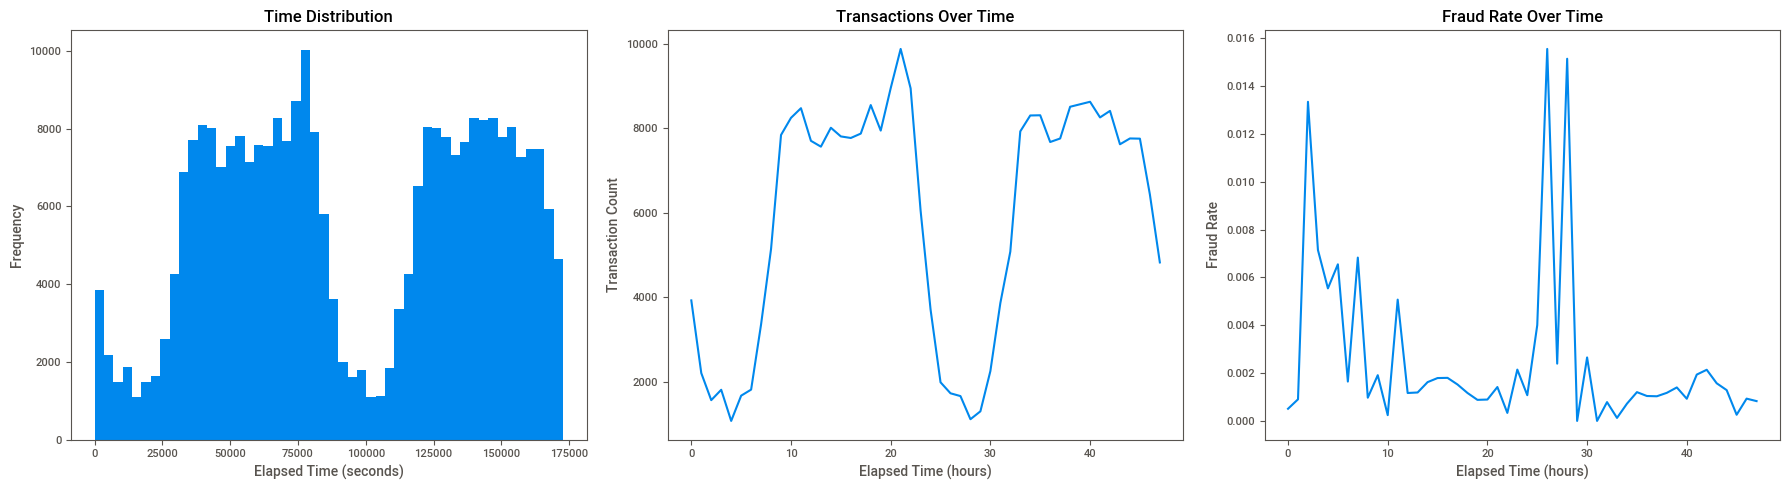

In [40]:
# Univariate analysis of the Time variable

print("Time Statistics:")
print(f"Minimum: {df['Time'].min():.0f} seconds")
print(f"Maximum: {df['Time'].max():.0f} seconds")
print(f"Mean: {df['Time'].mean():.0f} seconds")
print(f"Median: {df['Time'].median():.0f} seconds")

elapsed_hours = df["Time"] / 3600
hourly_data = df.groupby(elapsed_hours.astype(int))["Class"].agg(
    fraud_rate="mean",
    transaction_count="size"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["Time"], bins=50)
axes[0].set_title("Time Distribution")
axes[0].set_xlabel("Elapsed Time (seconds)")
axes[0].set_ylabel("Frequency")

axes[1].plot(hourly_data.index, hourly_data["transaction_count"])
axes[1].set_title("Transactions Over Time")
axes[1].set_xlabel("Elapsed Time (hours)")
axes[1].set_ylabel("Transaction Count")

axes[2].plot(hourly_data.index, hourly_data["fraud_rate"])
axes[2].set_title("Fraud Rate Over Time")
axes[2].set_xlabel("Elapsed Time (hours)")
axes[2].set_ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

Amount Statistics:
Minimum: $0.00
Maximum: $25691.16
Mean: $88.47
Median: $22.00
Standard deviation: $250.40

Amount Statistics by Class:
             mean  median
Class                    
0       88.413575   22.00
1      123.871860    9.82

Amount Percentiles:
0.10       1.0000
0.25       5.6000
0.50      22.0000
0.75      77.5100
0.90     203.3800
0.95     365.3375
0.99    1018.9650
Name: Amount, dtype: float64


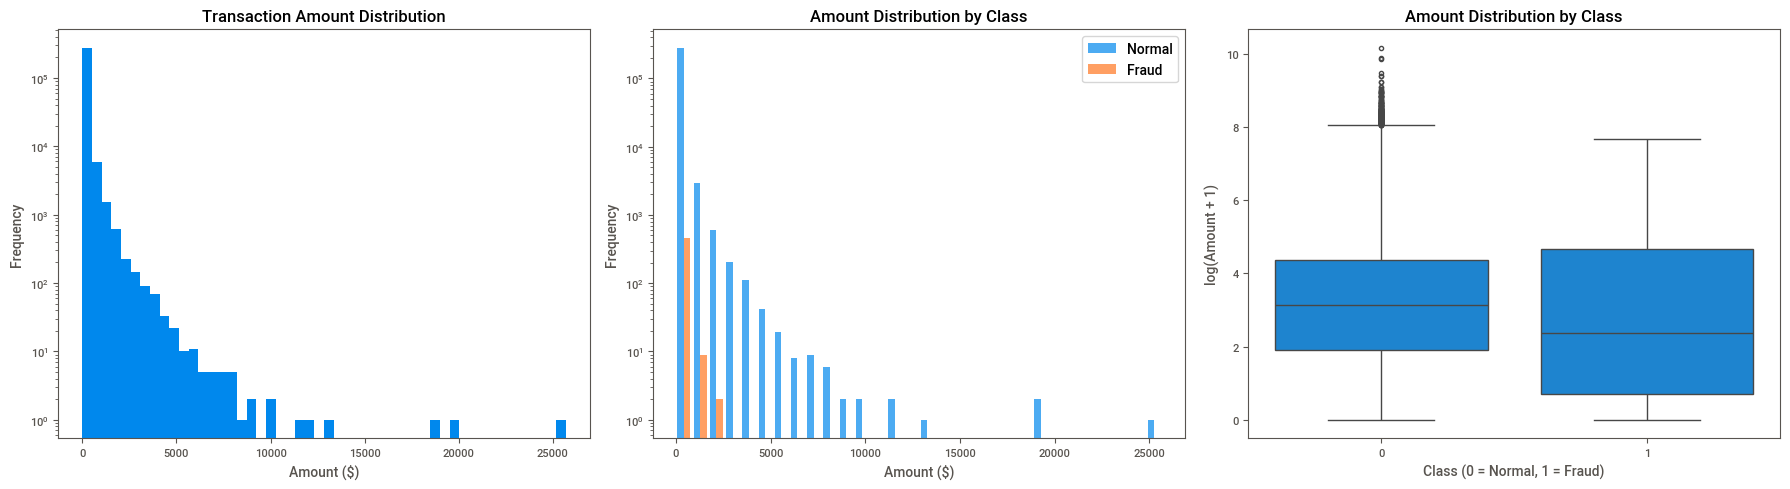

In [41]:
# Univariate analysis of the Amount variable

print("Amount Statistics:")
print(f"Minimum: ${df['Amount'].min():.2f}")
print(f"Maximum: ${df['Amount'].max():.2f}")
print(f"Mean: ${df['Amount'].mean():.2f}")
print(f"Median: ${df['Amount'].median():.2f}")
print(f"Standard deviation: ${df['Amount'].std():.2f}")

amount_by_class = df.groupby("Class")["Amount"].agg(["mean", "median"])
print("\nAmount Statistics by Class:")
print(amount_by_class)

percentiles = df["Amount"].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print("\nAmount Percentiles:")
print(percentiles)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["Amount"], bins=50)
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")

axes[1].hist(
    [df.loc[df["Class"] == 0, "Amount"],
     df.loc[df["Class"] == 1, "Amount"]],
    bins=30,
    label=["Normal", "Fraud"],
    alpha=0.7
)
axes[1].set_title("Amount Distribution by Class")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].legend()

df["Amount_Log"] = np.log1p(df["Amount"])

sns.boxplot(data=df, x="Class", y="Amount_Log", ax=axes[2])
axes[2].set_title("Amount Distribution by Class")
axes[2].set_xlabel("Class (0 = Normal, 1 = Fraud)")
axes[2].set_ylabel("log(Amount + 1)")

plt.tight_layout()
plt.show()

In [42]:
# Univariate analysis of PCA-transformed features (V1-V28)

v_columns = [f"V{i}" for i in range(1, 29)]

print("PCA-Transformed Features (V1-V28):")
print(f"Number of features: {len(v_columns)}")

v_stats = df[v_columns].describe()

print("\nSummary Statistics:")
print(f"Mean range: {v_stats.loc['mean'].min():.3f} to {v_stats.loc['mean'].max():.3f}")
print(f"Std range: {v_stats.loc['std'].min():.3f} to {v_stats.loc['std'].max():.3f}")
print(f"Minimum range: {v_stats.loc['min'].min():.3f} to {v_stats.loc['min'].max():.3f}")
print(f"Maximum range: {v_stats.loc['max'].min():.3f} to {v_stats.loc['max'].max():.3f}")

class_means = df.groupby("Class")[v_columns].mean().T
class_means.columns = ["Normal", "Fraud"]
class_means["Absolute Mean Difference"] = (
    class_means["Fraud"] - class_means["Normal"]
).abs()

print("\nTop 10 Features by Absolute Mean Difference:")
print(
    class_means.sort_values(
        "Absolute Mean Difference", ascending=False
    ).head(10)
)

PCA-Transformed Features (V1-V28):
Number of features: 28

Summary Statistics:
Mean range: -0.004 to 0.006
Std range: 0.328 to 1.948
Minimum range: -113.743 to -2.605
Maximum range: 2.455 to 120.589

Top 10 Features by Absolute Mean Difference:
       Normal     Fraud  Absolute Mean Difference
V14  0.011668 -6.835946                  6.847614
V3   0.012853 -6.729599                  6.742452
V17  0.010963 -6.463285                  6.474249
V12  0.009476 -6.103254                  6.112730
V10  0.007663 -5.453274                  5.460937
V7   0.010447 -5.175912                  5.186359
V1   0.013439 -4.498280                  4.511719
V4  -0.010440  4.472591                  4.483031
V16  0.007845 -4.000956                  4.008801
V11 -0.006004  3.716347                  3.722350


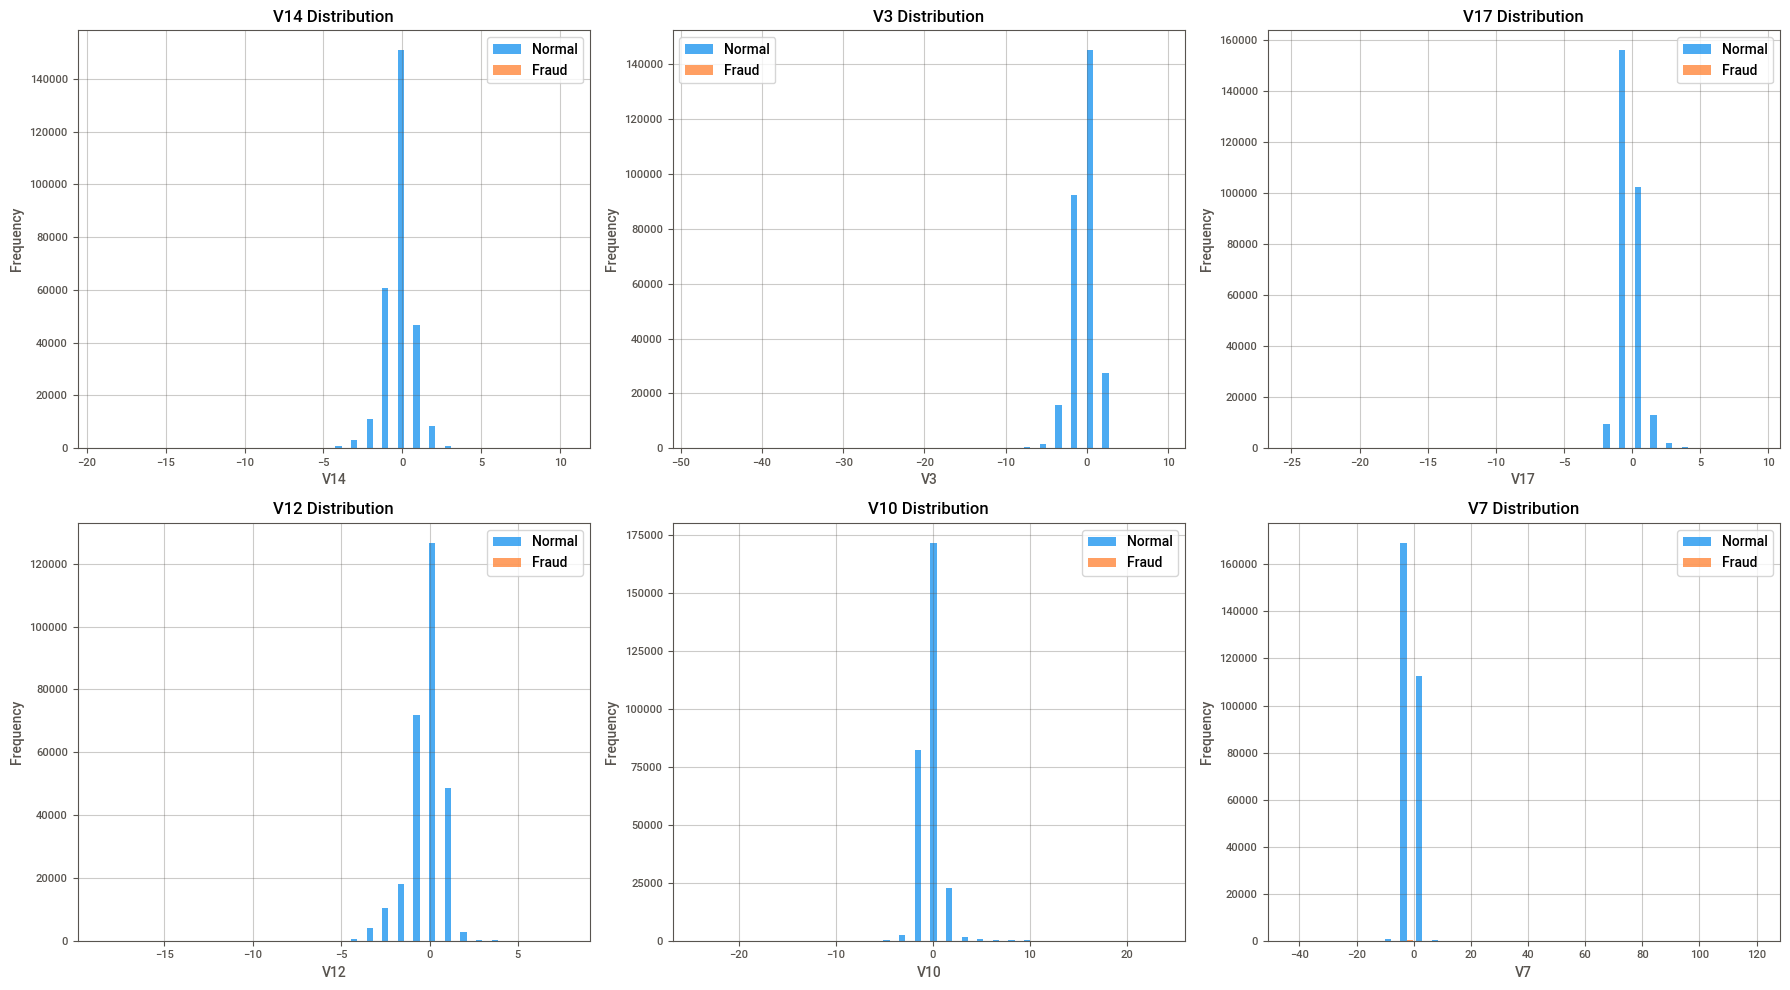


Univariate Analysis Summary
Fraud rate: 0.17%
Time span: 48.0 hours
Mean transaction amount: $88.47
PCA-transformed features analyzed: 28
Top feature by mean difference: V14


In [43]:
# Visualize top discriminative PCA-transformed features

top_components = class_means["Absolute Mean Difference"].nlargest(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, component in zip(axes, top_components):
    normal_data = df.loc[df["Class"] == 0, component]
    fraud_data = df.loc[df["Class"] == 1, component]

    ax.hist(
        [normal_data, fraud_data],
        bins=30,
        alpha=0.7,
        label=["Normal", "Fraud"]
    )
    ax.set_title(f"{component} Distribution")
    ax.set_xlabel(component)
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nUnivariate Analysis Summary")
print("=" * 35)
print(f"Fraud rate: {df['Class'].mean() * 100:.2f}%")
print(f"Time span: {(df['Time'].max() - df['Time'].min()) / 3600:.1f} hours")
print(f"Mean transaction amount: ${df['Amount'].mean():.2f}")
print(f"PCA-transformed features analyzed: {len(v_columns)}")
print(f"Top feature by mean difference: {top_components[0]}")

## Step 7: Bivariate Analysis - Find Relationships Between Variables

Let's analyze relationships between pairs of variables to understand how they interact and influence each other.


BIVARIATE ANALYSIS - RELATIONSHIPS BETWEEN VARIABLES

Top 10 Features Correlated with Class
----------------------------------------
 V17: -0.3135
 V14: -0.2934
 V12: -0.2507
 V10: -0.2070
 V16: -0.1872
  V3: -0.1823
  V7: -0.1723
 V11: 0.1491
  V4: 0.1293
 V18: -0.1053

Correlation Summary
----------------------------------------
Strongest positive correlation: 0.1491
Strongest negative correlation: -0.3135
Features with |correlation| > 0.1: 10


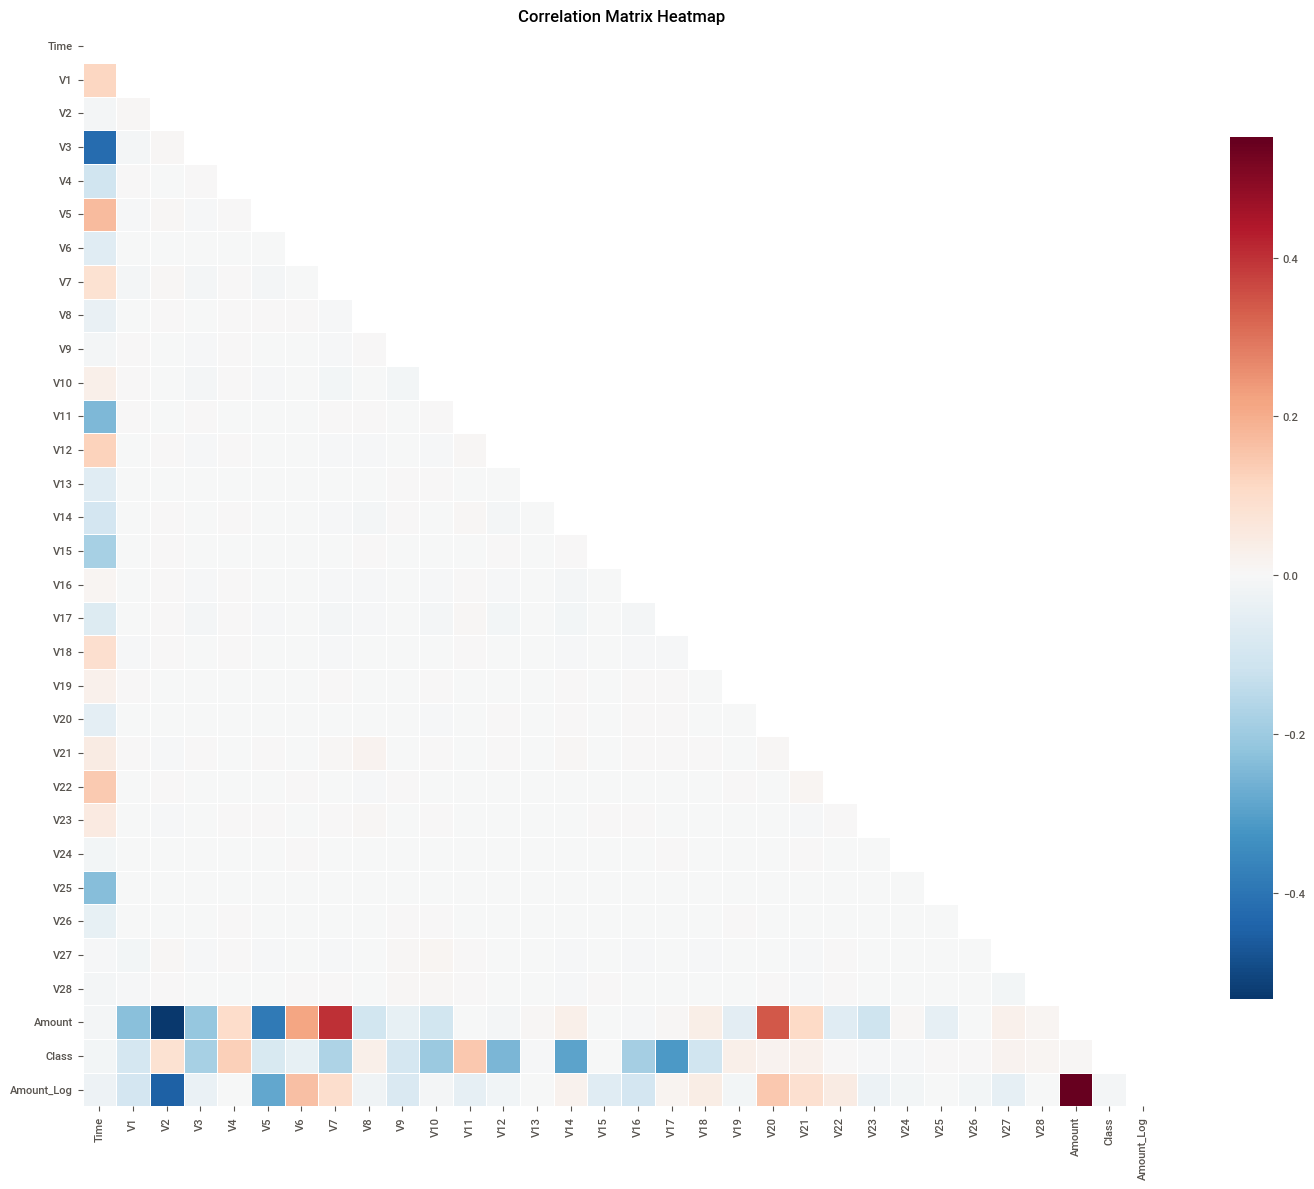

In [44]:
# Step 7: Bivariate Analysis

print("BIVARIATE ANALYSIS - RELATIONSHIPS BETWEEN VARIABLES")
print("=" * 55)

# Correlation analysis
correlation_matrix = df.corr(numeric_only=True)

class_correlations = (
    correlation_matrix["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

print("\nTop 10 Features Correlated with Class")
print("-" * 40)

for feature, corr in class_correlations.head(10).items():
    print(f"{feature:>4}: {corr:.4f}")

print("\nCorrelation Summary")
print("-" * 40)
print(f"Strongest positive correlation: {class_correlations.max():.4f}")
print(f"Strongest negative correlation: {class_correlations.min():.4f}")
print(f"Features with |correlation| > 0.1: {(class_correlations.abs() > 0.1).sum()}")

# Correlation heatmap
plt.figure(figsize=(15, 12))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


2. AMOUNT vs TIME ANALYSIS


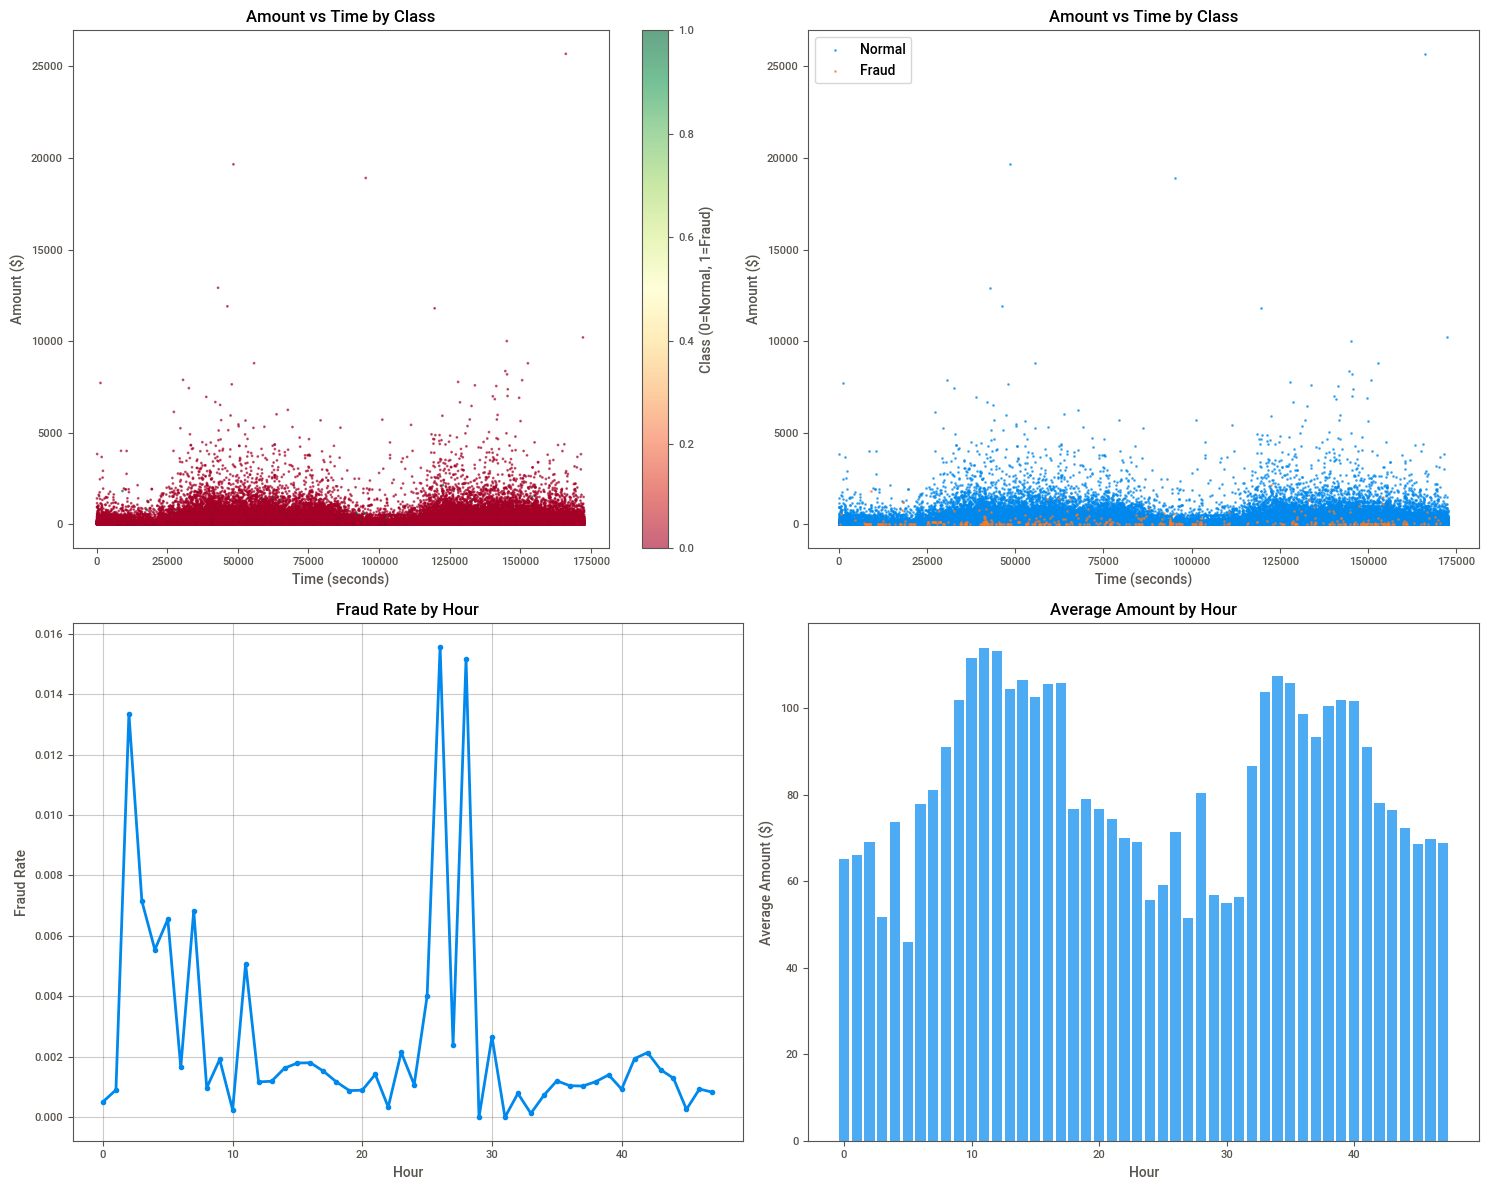

Correlation between Amount and Time: -0.0106

Fraud Analysis by Time and Amount:
Average fraud amount: $123.87
Average normal amount: $88.41
Fraud time range: 406 to 170348 seconds
Normal time range: 0 to 172792 seconds


In [45]:
# 2. Amount vs Time Analysis

print("\n2. AMOUNT vs TIME ANALYSIS")
print("=" * 35)

# Create hour feature for time-based analysis
df["Hour"] = (df["Time"] / 3600).astype(int)

# Separate transactions by class
normal_data = df[df["Class"] == 0]
fraud_data = df[df["Class"] == 1]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Amount vs Time colored by class
scatter = axes[0, 0].scatter(
    df["Time"], df["Amount"],
    c=df["Class"], cmap="RdYlGn",
    alpha=0.6, s=1
)
axes[0, 0].set_title("Amount vs Time by Class")
axes[0, 0].set_xlabel("Time (seconds)")
axes[0, 0].set_ylabel("Amount ($)")
plt.colorbar(scatter, ax=axes[0, 0], label="Class (0=Normal, 1=Fraud)")

# Amount vs Time separated by class
axes[0, 1].scatter(
    normal_data["Time"], normal_data["Amount"],
    alpha=0.6, s=1, label="Normal"
)
axes[0, 1].scatter(
    fraud_data["Time"], fraud_data["Amount"],
    alpha=0.6, s=1, label="Fraud"
)
axes[0, 1].set_title("Amount vs Time by Class")
axes[0, 1].set_xlabel("Time (seconds)")
axes[0, 1].set_ylabel("Amount ($)")
axes[0, 1].legend()

# Fraud rate by hour
hourly_fraud_rate = df.groupby("Hour")["Class"].mean()

axes[1, 0].plot(
    hourly_fraud_rate.index,
    hourly_fraud_rate.values,
    marker="o",
    linewidth=2
)
axes[1, 0].set_title("Fraud Rate by Hour")
axes[1, 0].set_xlabel("Hour")
axes[1, 0].set_ylabel("Fraud Rate")
axes[1, 0].grid(True, alpha=0.3)

# Average transaction amount by hour
hourly_amount = df.groupby("Hour")["Amount"].mean()

axes[1, 1].bar(
    hourly_amount.index,
    hourly_amount.values,
    alpha=0.7
)
axes[1, 1].set_title("Average Amount by Hour")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].set_ylabel("Average Amount ($)")

plt.tight_layout()
plt.show()

# Correlation between Amount and Time
amount_time_corr = df["Amount"].corr(df["Time"])
print(f"Correlation between Amount and Time: {amount_time_corr:.4f}")

# Fraud patterns by time and amount
print("\nFraud Analysis by Time and Amount:")
print(f"Average fraud amount: ${fraud_data['Amount'].mean():.2f}")
print(f"Average normal amount: ${normal_data['Amount'].mean():.2f}")
print(f"Fraud time range: {fraud_data['Time'].min():.0f} to {fraud_data['Time'].max():.0f} seconds")
print(f"Normal time range: {normal_data['Time'].min():.0f} to {normal_data['Time'].max():.0f} seconds")


3. V COMPONENTS RELATIONSHIPS ANALYSIS
Top 6 Most Discriminative V Components:
1. V14
2. V3
3. V17
4. V12
5. V10
6. V7


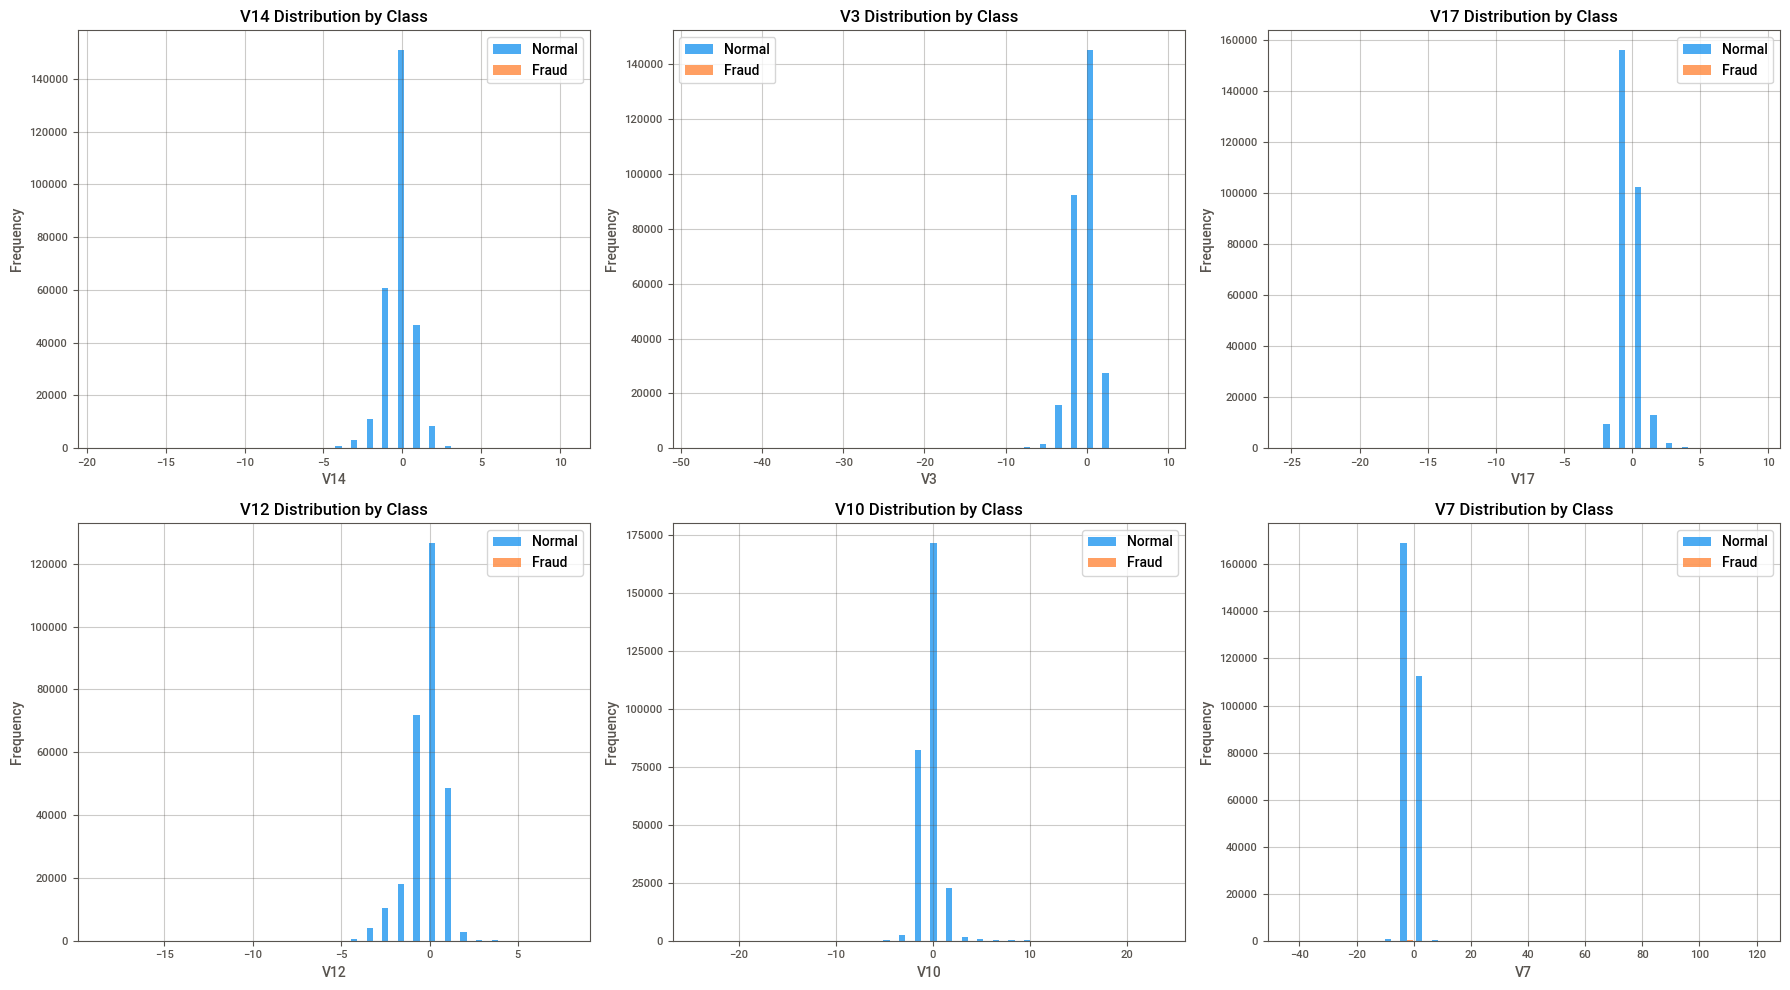


Correlations Between Top V Components:
        V14      V3     V17     V12     V10      V7
V14  1.0000 -0.0030 -0.0136 -0.0100  0.0002 -0.0038
V3  -0.0030  1.0000 -0.0082 -0.0059 -0.0096 -0.0117
V17 -0.0136 -0.0082  1.0000 -0.0129 -0.0079 -0.0088
V12 -0.0100 -0.0059 -0.0129  1.0000 -0.0069 -0.0062
V10  0.0002 -0.0096 -0.0079 -0.0069  1.0000 -0.0136
V7  -0.0038 -0.0117 -0.0088 -0.0062 -0.0136  1.0000

Strongest Correlations Between V Components:
1. V10 vs V7: -0.0136
2. V14 vs V17: -0.0136
3. V17 vs V12: -0.0129
4. V3 vs V7: -0.0117
5. V14 vs V12: -0.0100


In [47]:
# 3. V Components Relationships Analysis

print("\n3. V COMPONENTS RELATIONSHIPS ANALYSIS")
print("=" * 45)

# Select the top 6 V components based on class mean difference
top_v_components = (
    class_means["Absolute Mean Difference"]
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)

print("Top 6 Most Discriminative V Components:")
for i, component in enumerate(top_v_components, 1):
    print(f"{i}. {component}")

# Visualize the top V components by class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, component in enumerate(top_v_components):
    normal_data = df.loc[df["Class"] == 0, component]
    fraud_data = df.loc[df["Class"] == 1, component]

    axes[i].hist(
        [normal_data, fraud_data],
        bins=30,
        alpha=0.7,
        label=["Normal", "Fraud"]
    )
    
    axes[i].set_title(f"{component} Distribution by Class")
    axes[i].set_xlabel(component)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation matrix of the top V components
top_v_corr = df[top_v_components].corr()

print("\nCorrelations Between Top V Components:")
print(top_v_corr.round(4))

# Find the strongest pairwise correlations
v_corr_pairs = []

for i in range(len(top_v_components)):
    for j in range(i + 1, len(top_v_components)):
        comp1 = top_v_components[i]
        comp2 = top_v_components[j]
        corr = df[comp1].corr(df[comp2])
        v_corr_pairs.append((comp1, comp2, corr))

v_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("\nStrongest Correlations Between V Components:")
for i, (comp1, comp2, corr) in enumerate(v_corr_pairs[:5], 1):
    print(f"{i}. {comp1} vs {comp2}: {corr:.4f}")


4. FEATURE IMPORTANCE ANALYSIS
Feature Ranking by Absolute Correlation with Class:
 1. V17 : 0.3135
 2. V14 : 0.2934
 3. V12 : 0.2507
 4. V10 : 0.2070
 5. V16 : 0.1872
 6. V3  : 0.1823
 7. V7  : 0.1723
 8. V11 : 0.1491
 9. V4  : 0.1293
10. V18 : 0.1053
11. V1  : 0.0945
12. V9  : 0.0940
13. V5  : 0.0878
14. V2  : 0.0846
15. V6  : 0.0439


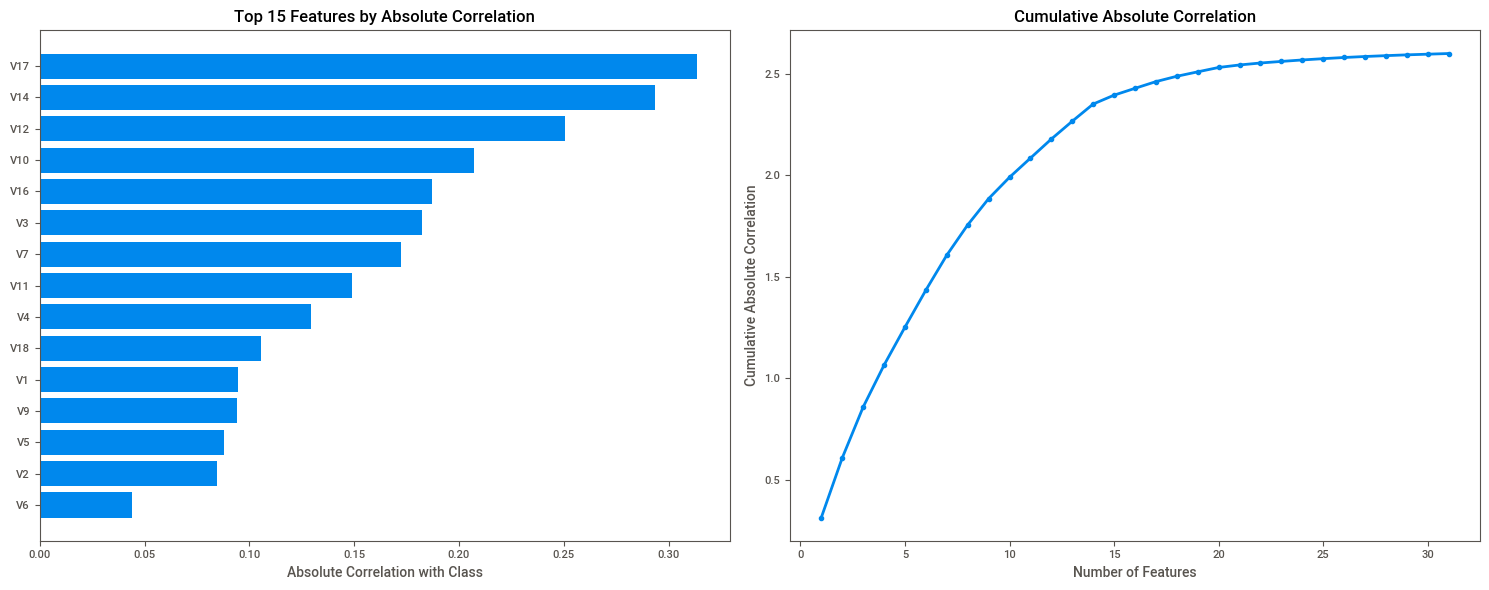

In [48]:
# 4. Feature Importance Analysis

print("\n4. FEATURE IMPORTANCE ANALYSIS")
print("=" * 40)

correlation_importance = class_correlations.abs().sort_values(ascending=False)

print("Feature Ranking by Absolute Correlation with Class:")

for i, (feature, importance) in enumerate(correlation_importance.head(15).items(), 1):
    print(f"{i:2d}. {feature:4s}: {importance:.4f}")

top_15_features = correlation_importance.head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    top_15_features.index[::-1],
    top_15_features.values[::-1]
)
axes[0].set_xlabel("Absolute Correlation with Class")
axes[0].set_title("Top 15 Features by Absolute Correlation")

cumulative_correlation = correlation_importance.cumsum()

axes[1].plot(
    range(1, len(cumulative_correlation) + 1),
    cumulative_correlation.values,
    marker="o",
    linewidth=2
)
axes[1].set_xlabel("Number of Features")
axes[1].set_ylabel("Cumulative Absolute Correlation")
axes[1].set_title("Cumulative Absolute Correlation")

plt.tight_layout()
plt.show()

In [50]:
# 5. Bivariate Analysis Summary

class_correlations = df.corr(numeric_only=True)["Class"].drop("Class")
feature_importance = class_correlations.abs().sort_values(ascending=False)

print("\nBIVARIATE ANALYSIS SUMMARY")
print("=" * 40)

print("KEY RELATIONSHIPS:")
print(
    f"Strongest correlation with Class: "
    f"{class_correlations.abs().idxmax()} "
    f"({class_correlations[class_correlations.abs().idxmax()]:.4f})"
)
print(
    f"Weakest correlation with Class: "
    f"{class_correlations.abs().idxmin()} "
    f"({class_correlations[class_correlations.abs().idxmin()]:.4f})"
)
print(f"Amount-Time correlation: {amount_time_corr:.4f}")

print("\nFEATURE INSIGHTS:")
print(
    f"Most important feature: "
    f"{feature_importance.index[0]} ({feature_importance.iloc[0]:.4f})"
)
print(f"Top 5 features: {', '.join(feature_importance.head(5).index)}")
print(f"Features with |correlation| > 0.1: {(class_correlations.abs() > 0.1).sum()}")

print("\nFRAUD DETECTION INSIGHTS:")
print("V components show differences between normal and fraudulent transactions.")
print("Time patterns can be examined for differences in fraud occurrence.")
print("Transaction amount distributions differ between normal and fraudulent transactions.")
print("Correlation analysis helps identify potentially useful predictors.")

print("\nBIVARIATE ANALYSIS COMPLETE")


BIVARIATE ANALYSIS SUMMARY
KEY RELATIONSHIPS:
Strongest correlation with Class: V17 (-0.3135)
Weakest correlation with Class: V25 (0.0032)
Amount-Time correlation: -0.0106

FEATURE INSIGHTS:
Most important feature: V17 (0.3135)
Top 5 features: V17, V14, V12, V10, V16
Features with |correlation| > 0.1: 10

FRAUD DETECTION INSIGHTS:
V components show differences between normal and fraudulent transactions.
Time patterns can be examined for differences in fraud occurrence.
Transaction amount distributions differ between normal and fraudulent transactions.
Correlation analysis helps identify potentially useful predictors.

BIVARIATE ANALYSIS COMPLETE


## Step 8: Detect Outliers - Handle Anomalies in the Data

Let's identify and analyze outliers in our dataset to understand their impact on fraud detection.


In [51]:
def detect_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower_bound) | (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


outlier_columns = ["Amount", "Time"] + top_v_components[:5]
outlier_summary = {}

print("OUTLIER DETECTION USING IQR")
print("=" * 35)

for col in outlier_columns:
    outliers, lower_bound, upper_bound = detect_outliers_iqr(df, col)

    count = len(outliers)
    percentage = count / len(df) * 100

    outlier_summary[col] = {
        "count": count,
        "percentage": percentage,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }

    print(f"{col}: {count:,} outliers ({percentage:.2f}%)")
    print(f"Range: [{lower_bound:.2f}, {upper_bound:.2f}]")

total_outliers = sum(info["count"] for info in outlier_summary.values())
print(f"\nTotal outliers across columns: {total_outliers:,}")

OUTLIER DETECTION USING IQR
Amount: 31,685 outliers (11.17%)
Range: [-102.27, 185.38]
Time: 0 outliers (0.00%)
Range: [-73435.12, 266937.88]
V14: 14,060 outliers (4.96%)
Range: [-1.80, 1.87]
V3: 3,306 outliers (1.17%)
Range: [-3.76, 3.90]
V17: 7,353 outliers (2.59%)
Range: [-1.81, 1.72]
V12: 15,282 outliers (5.39%)
Range: [-1.94, 2.15]
V10: 9,345 outliers (3.29%)
Range: [-2.02, 1.94]

Total outliers across columns: 81,031


In [52]:
# 2. Outlier Analysis by Class
print("\n2. OUTLIER ANALYSIS BY CLASS")
print("=" * 35)

fraud_data = df[df["Class"] == 1]
normal_data = df[df["Class"] == 0]

fraud_outliers = {}
normal_outliers = {}

for col in outlier_columns:
    if col in df.columns:
        fraud_outliers[col], _, _ = detect_outliers_iqr(fraud_data, col)
        normal_outliers[col], _, _ = detect_outliers_iqr(normal_data, col)

        fraud_count = len(fraud_outliers[col])
        normal_count = len(normal_outliers[col])

        print(f"{col}:")
        print(f"  Fraud outliers: {fraud_count:,} ({fraud_count / len(fraud_data) * 100:.2f}%)")
        print(f"  Normal outliers: {normal_count:,} ({normal_count / len(normal_data) * 100:.2f}%)")

print("\nOUTLIER-FRAUD RELATIONSHIP")

overall_fraud_rate = df["Class"].mean()

for col in outlier_columns:
    if col in df.columns:
        outliers, _, _ = detect_outliers_iqr(df, col)

        if len(outliers) > 0:
            fraud_rate = outliers["Class"].mean()

            print(f"{col}:")
            print(f"  Fraud rate in outliers: {fraud_rate:.2%}")
            print(f"  Overall fraud rate: {overall_fraud_rate:.2%}")
            print(f"  Outlier fraud ratio: {fraud_rate / overall_fraud_rate:.2f}x")


2. OUTLIER ANALYSIS BY CLASS
Amount:
  Fraud outliers: 67 (14.16%)
  Normal outliers: 31,621 (11.16%)
Time:
  Fraud outliers: 0 (0.00%)
  Normal outliers: 0 (0.00%)
V14:
  Fraud outliers: 7 (1.48%)
  Normal outliers: 13,737 (4.85%)
V3:
  Fraud outliers: 56 (11.84%)
  Normal outliers: 3,058 (1.08%)
V17:
  Fraud outliers: 0 (0.00%)
  Normal outliers: 6,986 (2.47%)
V12:
  Fraud outliers: 6 (1.27%)
  Normal outliers: 15,010 (5.30%)
V10:
  Fraud outliers: 22 (4.65%)
  Normal outliers: 8,991 (3.17%)

OUTLIER-FRAUD RELATIONSHIP
Amount:
  Fraud rate in outliers: 0.27%
  Overall fraud rate: 0.17%
  Outlier fraud ratio: 1.65x
V14:
  Fraud rate in outliers: 2.92%
  Overall fraud rate: 0.17%
  Outlier fraud ratio: 17.53x
V3:
  Fraud rate in outliers: 8.86%
  Overall fraud rate: 0.17%
  Outlier fraud ratio: 53.16x
V17:
  Fraud rate in outliers: 5.15%
  Overall fraud rate: 0.17%
  Outlier fraud ratio: 30.92x
V12:
  Fraud rate in outliers: 2.55%
  Overall fraud rate: 0.17%
  Outlier fraud ratio: 15.


3. OUTLIER VISUALIZATION


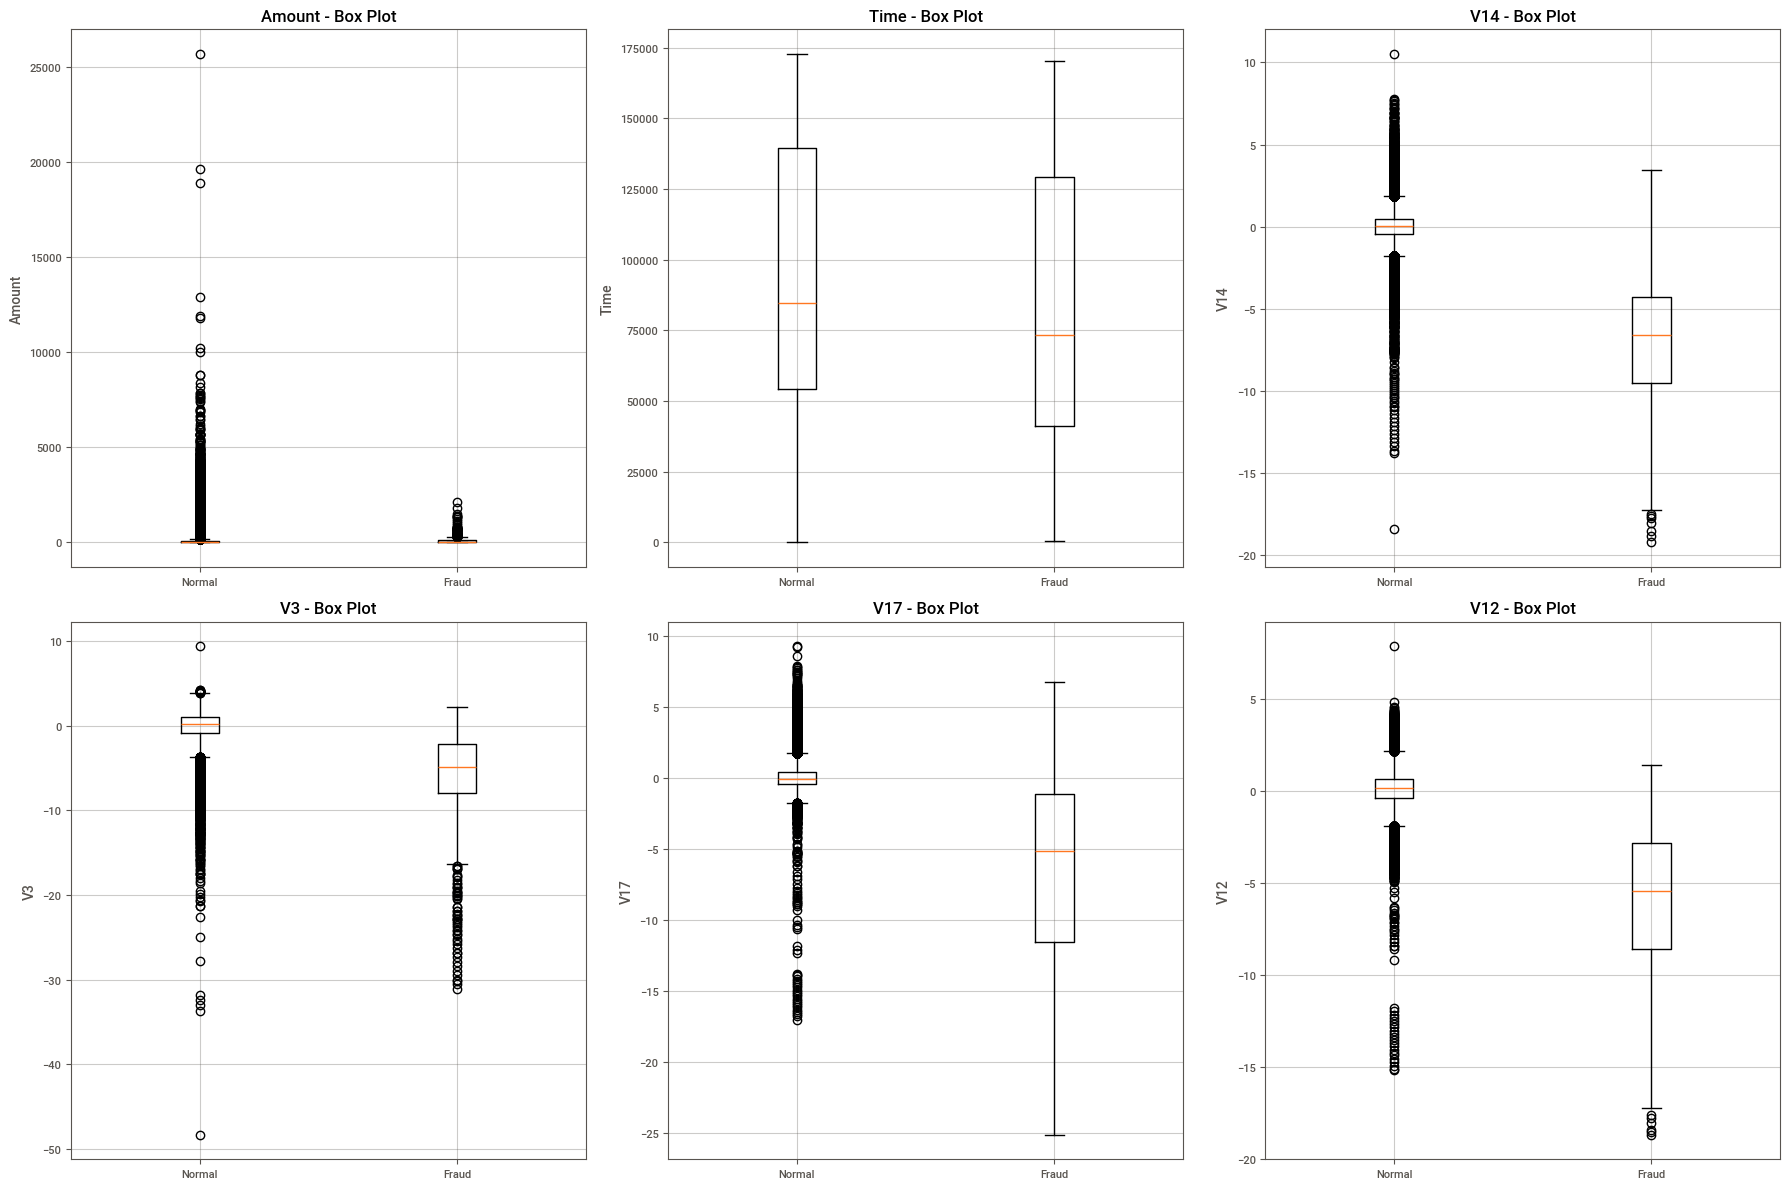

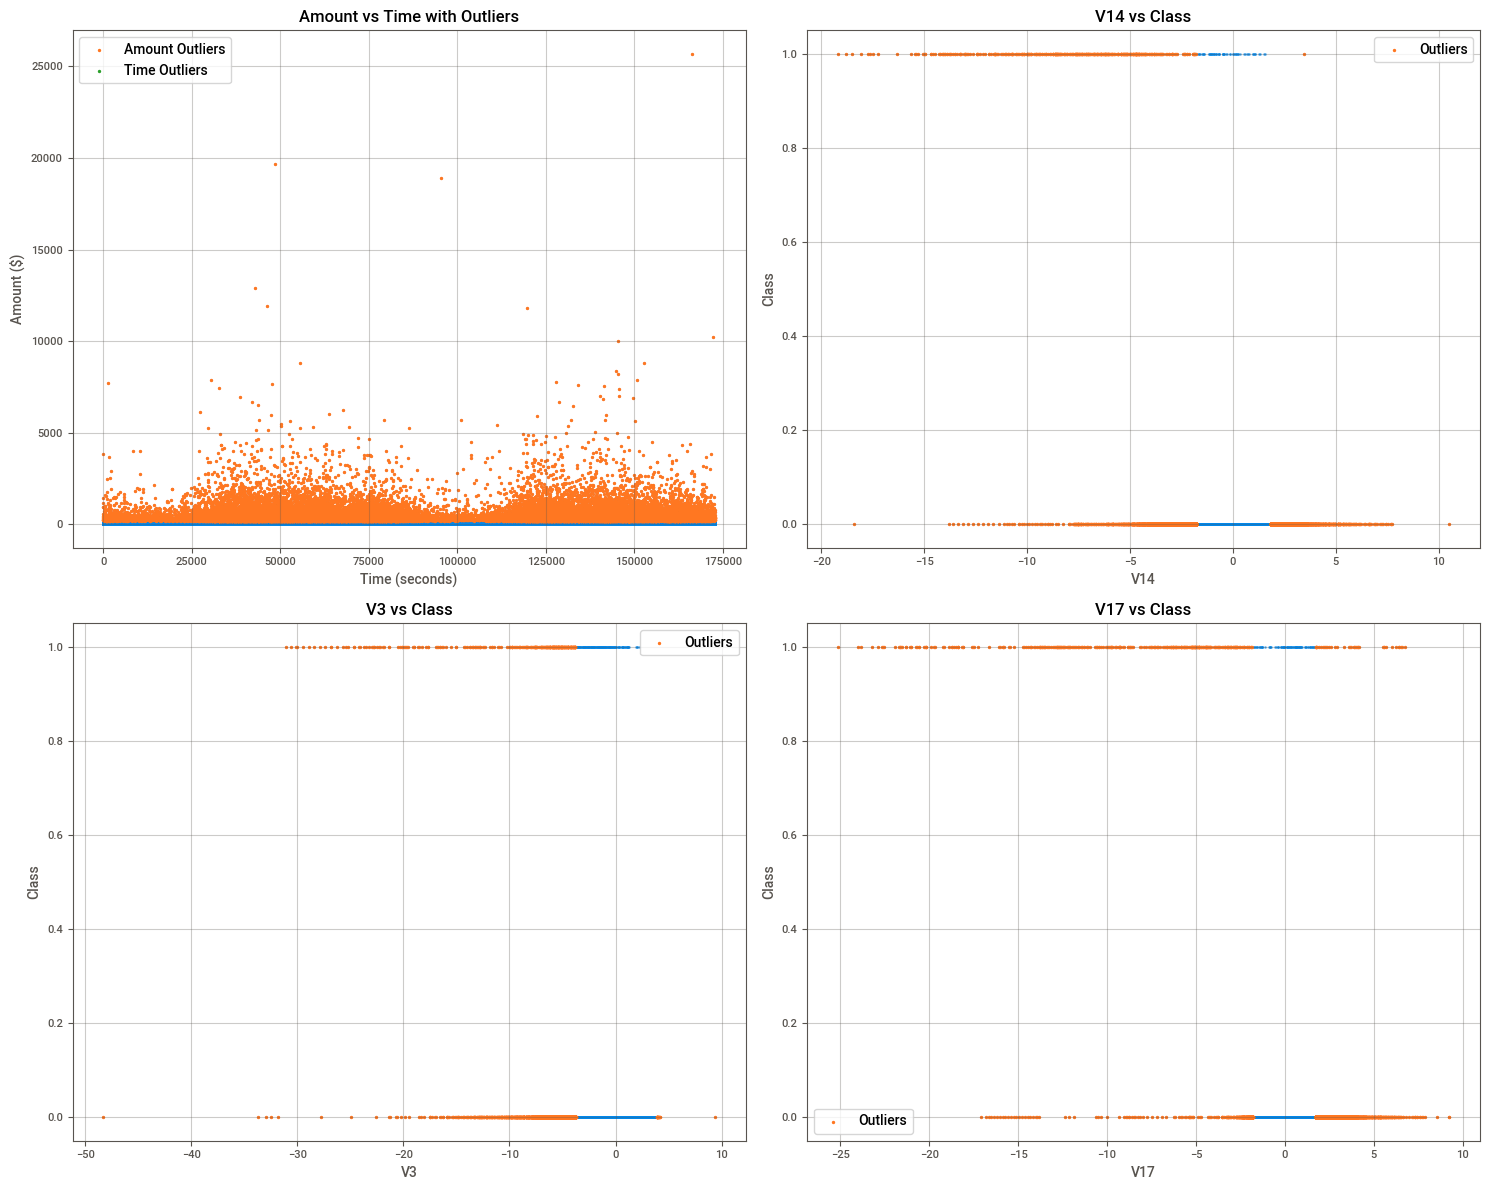

In [53]:
# 3. Outlier Visualization

print("\n3. OUTLIER VISUALIZATION")
print("=" * 30)

# Box plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

plot_columns = ['Amount', 'Time'] + top_v_components[:4]

for i, col in enumerate(plot_columns):
    data = [
        df.loc[df['Class'] == 0, col],
        df.loc[df['Class'] == 1, col]
    ]

    axes[i // 3, i % 3].boxplot(data, labels=['Normal', 'Fraud'])
    axes[i // 3, i % 3].set_title(f'{col} - Box Plot')
    axes[i // 3, i % 3].set_ylabel(col)
    axes[i // 3, i % 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plots with outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

outliers_amount, _, _ = detect_outliers_iqr(df, 'Amount')
outliers_time, _, _ = detect_outliers_iqr(df, 'Time')

axes[0, 0].scatter(df['Time'], df['Amount'], alpha=0.5, s=1)
axes[0, 0].scatter(
    outliers_amount['Time'], outliers_amount['Amount'],
    s=2, label='Amount Outliers'
)
axes[0, 0].scatter(
    outliers_time['Time'], outliers_time['Amount'],
    s=2, label='Time Outliers'
)
axes[0, 0].set_title('Amount vs Time with Outliers')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Amount ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for i, col in enumerate(top_v_components[:3]):
    ax = axes[(i + 1) // 2, (i + 1) % 2]
    outliers, _, _ = detect_outliers_iqr(df, col)

    ax.scatter(df[col], df['Class'], alpha=0.5, s=1)
    ax.scatter(
        outliers[col], outliers['Class'],
        s=2, label='Outliers'
    )
    ax.set_title(f'{col} vs Class')
    ax.set_xlabel(col)
    ax.set_ylabel('Class')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
# 4. Outlier Handling Strategies

print("\n4. OUTLIER HANDLING STRATEGIES:")
print("=" * 40)

print("OUTLIER HANDLING OPTIONS:")
print("1. Keep outliers (recommended for fraud detection)")
print("   - Outliers may be legitimate fraud cases")
print("   - Removing them could reduce model performance")
print("   - Fraud detection benefits from anomaly detection")

print("\n2. Cap outliers (winsorization)")
print("   - Replace extreme values with percentiles")
print("   - Preserves data distribution shape")
print("   - Reduces impact of extreme values")

print("\n3. Remove outliers (not recommended)")
print("   - Could remove important fraud cases")
print("   - May reduce dataset size significantly")
print("   - Could introduce bias")

# Demonstrate winsorization for Amount
print("\nWINSORIZATION EXAMPLE (Amount):")

amount_q1 = df["Amount"].quantile(0.01)
amount_q99 = df["Amount"].quantile(0.99)

print(
    f"Original Amount range: "
    f"${df['Amount'].min():.2f} to ${df['Amount'].max():.2f}"
)

print(
    f"Winsorization bounds: "
    f"${amount_q1:.2f} to ${amount_q99:.2f}"
)

# Count values that would be capped
values_to_cap_low = (df["Amount"] < amount_q1).sum()
values_to_cap_high = (df["Amount"] > amount_q99).sum()

print(f"Values to cap (low): {values_to_cap_low:,}")
print(f"Values to cap (high): {values_to_cap_high:,}")

# Check if capping would affect fraud cases
fraud_affected_low = df[
    (df["Amount"] < amount_q1) & (df["Class"] == 1)
].shape[0]

fraud_affected_high = df[
    (df["Amount"] > amount_q99) & (df["Class"] == 1)
].shape[0]

print(f"Fraud cases affected (low cap): {fraud_affected_low}")
print(f"Fraud cases affected (high cap): {fraud_affected_high}")


4. OUTLIER HANDLING STRATEGIES:
OUTLIER HANDLING OPTIONS:
1. Keep outliers (recommended for fraud detection)
   - Outliers may be legitimate fraud cases
   - Removing them could reduce model performance
   - Fraud detection benefits from anomaly detection

2. Cap outliers (winsorization)
   - Replace extreme values with percentiles
   - Preserves data distribution shape
   - Reduces impact of extreme values

3. Remove outliers (not recommended)
   - Could remove important fraud cases
   - May reduce dataset size significantly
   - Could introduce bias

WINSORIZATION EXAMPLE (Amount):
Original Amount range: $0.00 to $25691.16
Winsorization bounds: $0.12 to $1018.97
Values to cap (low): 2,752
Values to cap (high): 2,838
Fraud cases affected (low cap): 30
Fraud cases affected (high cap): 9


In [55]:
# 5. Outlier Analysis Summary

print("\n5. OUTLIER ANALYSIS SUMMARY:")
print("=" * 35)

print("OUTLIER DETECTION RESULTS:")

total_outliers = sum(
    [info['count'] for info in outlier_summary.values()]
)

print(f"Total outliers detected: {total_outliers:,}")

print(
    f"Columns with most outliers: "
    f"{max(outlier_summary.items(), key=lambda x: x[1]['count'])[0]}"
)

print("\nOUTLIER IMPACT ANALYSIS:")

# Calculate overall outlier impact
outlier_impact = {}

for col, info in outlier_summary.items():

    if info['count'] > 0:

        outliers, _, _ = detect_outliers_iqr(df, col)

        fraud_in_outliers = outliers['Class'].sum()

        fraud_rate_in_outliers = fraud_in_outliers / len(outliers)

        outlier_impact[col] = fraud_rate_in_outliers

if outlier_impact:

    best_outlier_predictor = max(
        outlier_impact.items(),
        key=lambda x: x[1]
    )

    print(
        f"Best outlier predictor: "
        f"{best_outlier_predictor[0]} "
        f"(fraud rate: {best_outlier_predictor[1]:.4f})"
    )

print("\nFRAUD DETECTION INSIGHTS:")

print("Outliers may indicate fraudulent behavior")
print("Extreme values in V components could be fraud indicators")
print("High amounts might be associated with fraud")
print("Time outliers could indicate unusual transaction patterns")

print("\nRECOMMENDATION:")

print("KEEP ALL OUTLIERS for fraud detection")
print("Outliers are valuable for anomaly detection")
print("Consider using outlier detection as a feature")
print("Monitor outlier patterns for fraud indicators")

print("\nOUTLIER ANALYSIS COMPLETE!")
print("Outliers have been identified and analyzed for fraud detection insights.")


5. OUTLIER ANALYSIS SUMMARY:
OUTLIER DETECTION RESULTS:
Total outliers detected: 81,031
Columns with most outliers: Amount

OUTLIER IMPACT ANALYSIS:
Best outlier predictor: V3 (fraud rate: 0.0886)

FRAUD DETECTION INSIGHTS:
Outliers may indicate fraudulent behavior
Extreme values in V components could be fraud indicators
High amounts might be associated with fraud
Time outliers could indicate unusual transaction patterns

RECOMMENDATION:
KEEP ALL OUTLIERS for fraud detection
Outliers are valuable for anomaly detection
Consider using outlier detection as a feature
Monitor outlier patterns for fraud indicators

OUTLIER ANALYSIS COMPLETE!
Outliers have been identified and analyzed for fraud detection insights.


## Step 9: Feature Engineering - Improve Data Representation

Let's create new features and improve the data representation to enhance fraud detection capabilities.


In [56]:
# STEP 9: FEATURE ENGINEERING

print("FEATURE ENGINEERING - IMPROVING DATA REPRESENTATION")

print("=" * 65)

# Create a copy of the dataset for feature engineering
df_engineered = df.copy()

print("Original dataset shape:", df_engineered.shape)

# 1. Time-based Features

print("\n1. TIME-BASED FEATURE ENGINEERING:")

print("=" * 40)

# Convert Time into hours since the first transaction
df_engineered['Time_Since_Start'] = df_engineered['Time'] / 3600

# Extract hour of day using elapsed time
df_engineered['Hour_of_Day'] = (df_engineered['Time'] / 3600) % 24

# Create time-based categorical features
df_engineered['Time_Period'] = pd.cut(
    df_engineered['Hour_of_Day'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening'],
    include_lowest=True
)

print("Time-based features created:")
print("  - Hour_of_Day: Approximate hour based on elapsed time")
print("  - Time_Since_Start: Hours since first transaction")
print("  - Time_Period: Categorical time period")

# Analyze time-based features

print("\nTime-based feature analysis:")

print(
    f"  - Hour range: "
    f"{df_engineered['Hour_of_Day'].min():.1f} "
    f"to {df_engineered['Hour_of_Day'].max():.1f}"
)

print(
    f"  - Time since start: "
    f"{df_engineered['Time_Since_Start'].min():.1f} "
    f"to {df_engineered['Time_Since_Start'].max():.1f} hours"
)

print("  - Time periods distribution:")

period_counts = df_engineered['Time_Period'].value_counts()

for period, count in period_counts.items():
    print(
        f"    - {period}: "
        f"{count:,} ({count / len(df_engineered) * 100:.1f}%)"
    )

FEATURE ENGINEERING - IMPROVING DATA REPRESENTATION
Original dataset shape: (283726, 33)

1. TIME-BASED FEATURE ENGINEERING:
Time-based features created:
  - Hour_of_Day: Approximate hour based on elapsed time
  - Time_Since_Start: Hours since first transaction
  - Time_Period: Categorical time period

Time-based feature analysis:
  - Hour range: 0.0 to 24.0
  - Time since start: 0.0 to 48.0 hours
  - Time periods distribution:
    - Afternoon: 96,119 (33.9%)
    - Evening: 93,116 (32.8%)
    - Morning: 70,648 (24.9%)
    - Night: 23,843 (8.4%)


In [57]:
# 2. Amount-based Features

print("\n2. AMOUNT-BASED FEATURE ENGINEERING:")
print("=" * 40)

# Create amount-based features
df_engineered['Amount_Log'] = np.log1p(df_engineered['Amount'])
df_engineered['Amount_Sqrt'] = np.sqrt(df_engineered['Amount'])

# Amount categories
df_engineered['Amount_Category'] = pd.cut(
    df_engineered['Amount'],
    bins=[0, 10, 50, 100, 500, float('inf')],
    labels=['Micro', 'Small', 'Medium', 'Large', 'Very_Large'],
    include_lowest=True
)

# Amount percentile rank
df_engineered['Amount_Percentile'] = df_engineered['Amount'].rank(pct=True)

# High amount indicator
amount_95th = df_engineered['Amount'].quantile(0.95)
df_engineered['High_Amount'] = (
    df_engineered['Amount'] > amount_95th
).astype(int)

print("Amount-based features created:")
print("  - Amount_Log: Log-transformed amount")
print("  - Amount_Sqrt: Square root transformed amount")
print("  - Amount_Category: Categorical amount ranges")
print("  - Amount_Percentile: Amount percentile rank")
print("  - High_Amount: Binary high amount indicator")

# Analyze amount-based features
print("\nAmount-based feature analysis:")
print(f"  - 95th percentile threshold: ${amount_95th:.2f}")
print(
    f"  - High amount transactions: "
    f"{df_engineered['High_Amount'].sum():,} "
    f"({df_engineered['High_Amount'].mean() * 100:.1f}%)"
)

print("  - Amount categories distribution:")

category_counts = df_engineered['Amount_Category'].value_counts()

for category, count in category_counts.items():
    print(
        f"    - {category}: "
        f"{count:,} "
        f"({count / len(df_engineered) * 100:.1f}%)"
    )


2. AMOUNT-BASED FEATURE ENGINEERING:
Amount-based features created:
  - Amount_Log: Log-transformed amount
  - Amount_Sqrt: Square root transformed amount
  - Amount_Category: Categorical amount ranges
  - Amount_Percentile: Amount percentile rank
  - High_Amount: Binary high amount indicator

Amount-based feature analysis:
  - 95th percentile threshold: $365.34
  - High amount transactions: 14,187 (5.0%)
  - Amount categories distribution:
    - Micro: 99,821 (35.2%)
    - Small: 90,327 (31.8%)
    - Large: 47,290 (16.7%)
    - Medium: 37,179 (13.1%)
    - Very_Large: 9,109 (3.2%)


In [58]:
# 3. V Components Feature Engineering

print("\n3. V COMPONENTS FEATURE ENGINEERING:")
print("=" * 40)

# Create V component interaction features
v_columns = [f'V{i}' for i in range(1, 29)]

# V component statistics
df_engineered['V_Sum'] = df_engineered[v_columns].sum(axis=1)
df_engineered['V_Mean'] = df_engineered[v_columns].mean(axis=1)
df_engineered['V_Std'] = df_engineered[v_columns].std(axis=1)
df_engineered['V_Max'] = df_engineered[v_columns].max(axis=1)
df_engineered['V_Min'] = df_engineered[v_columns].min(axis=1)

# Get top 5 discriminative V components
top_v_components = (
    class_means['Absolute Mean Difference']
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Top 5 discriminative V components:")
for i, component in enumerate(top_v_components, 1):
    print(f"  {i}. {component}")

# V component interaction features
for i, comp1 in enumerate(top_v_components):
    for comp2 in top_v_components[i + 1:]:
        interaction_name = f'{comp1}_{comp2}_interaction'
        df_engineered[interaction_name] = (
            df_engineered[comp1] * df_engineered[comp2]
        )

# V component squared features
for comp in top_v_components[:3]:
    df_engineered[f'{comp}_squared'] = df_engineered[comp] ** 2

print("\nV components features created:")
print("  • V_Sum: Sum of all V components")
print("  • V_Mean: Mean of all V components")
print("  • V_Std: Standard deviation of V components")
print("  • V_Max: Maximum V component value")
print("  • V_Min: Minimum V component value")

interaction_count = len([
    col for col in df_engineered.columns
    if 'interaction' in col
])

squared_count = len([
    col for col in df_engineered.columns
    if 'squared' in col
])

print(f"  • {interaction_count} interaction features")
print(f"  • {squared_count} squared features")

# Analyze V component features
print("\nV components feature analysis:")
print(
    f"  • V_Sum range: "
    f"{df_engineered['V_Sum'].min():.3f} "
    f"to {df_engineered['V_Sum'].max():.3f}"
)

print(
    f"  • V_Mean range: "
    f"{df_engineered['V_Mean'].min():.3f} "
    f"to {df_engineered['V_Mean'].max():.3f}"
)

print(
    f"  • V_Std range: "
    f"{df_engineered['V_Std'].min():.3f} "
    f"to {df_engineered['V_Std'].max():.3f}"
)


3. V COMPONENTS FEATURE ENGINEERING:
Top 5 discriminative V components:
  1. V14
  2. V3
  3. V17
  4. V12
  5. V10

V components features created:
  • V_Sum: Sum of all V components
  • V_Mean: Mean of all V components
  • V_Std: Standard deviation of V components
  • V_Max: Maximum V component value
  • V_Min: Minimum V component value
  • 10 interaction features
  • 3 squared features

V components feature analysis:
  • V_Sum range: -198.355 to 22.450
  • V_Mean range: -7.084 to 0.802
  • V_Std range: 0.390 to 40.276


In [59]:
# 4. Risk Score Feature Engineering

print("\n4. RISK SCORE FEATURE ENGINEERING:")
print("=" * 40)

# Create risk score based on multiple factors
df_engineered["Risk_Score"] = 0

# Time-based risk
df_engineered["Time_Risk"] = np.where(
    (df_engineered["Hour_of_Day"] < 6) | (df_engineered["Hour_of_Day"] > 22),
    2,
    np.where(
        (df_engineered["Hour_of_Day"] < 8) | (df_engineered["Hour_of_Day"] > 20),
        1,
        0
    )
)

# Amount-based risk
df_engineered["Amount_Risk"] = np.where(
    df_engineered["Amount"] > amount_95th,
    2,
    np.where(
        df_engineered["Amount"] > df_engineered["Amount"].quantile(0.90),
        1,
        0
    )
)

# V component risk
df_engineered["V_Risk"] = 0

for comp in top_v_components[:3]:

    comp_q1 = df_engineered[comp].quantile(0.25)
    comp_q3 = df_engineered[comp].quantile(0.75)
    comp_iqr = comp_q3 - comp_q1

    comp_lower = comp_q1 - 1.5 * comp_iqr
    comp_upper = comp_q3 + 1.5 * comp_iqr

    extreme_values = (
        (df_engineered[comp] < comp_lower) |
        (df_engineered[comp] > comp_upper)
    )

    df_engineered["V_Risk"] += extreme_values.astype(int)

# Combined risk score
df_engineered["Risk_Score"] = (
    df_engineered["Time_Risk"]
    + df_engineered["Amount_Risk"]
    + df_engineered["V_Risk"]
)

# Risk categories
df_engineered["Risk_Category"] = pd.cut(
    df_engineered["Risk_Score"],
    bins=[-1, 0, 2, 4, 10],
    labels=["Low", "Medium", "High", "Very_High"],
    include_lowest=True
)

print("Risk score features created:")
print("  - Time_Risk: Risk based on transaction time")
print("  - Amount_Risk: Risk based on transaction amount")
print("  - V_Risk: Risk based on V component extremes")
print("  - Risk_Score: Combined risk score")
print("  - Risk_Category: Categorical risk levels")

# Analyze risk features
print("\nRisk feature analysis:")
print(
    f"  - Risk score range: "
    f"{df_engineered['Risk_Score'].min()} to "
    f"{df_engineered['Risk_Score'].max()}"
)

print("  - Risk categories distribution:")

risk_distribution = df_engineered["Risk_Category"].value_counts()

for category in risk_distribution.index:
    count = risk_distribution[category]
    print(f"    - {category}: {count:,} ({count / len(df_engineered) * 100:.1f}%)")


4. RISK SCORE FEATURE ENGINEERING:
Risk score features created:
  - Time_Risk: Risk based on transaction time
  - Amount_Risk: Risk based on transaction amount
  - V_Risk: Risk based on V component extremes
  - Risk_Score: Combined risk score
  - Risk_Category: Categorical risk levels

Risk feature analysis:
  - Risk score range: 0 to 7
  - Risk categories distribution:
    - Low: 158,333 (55.8%)
    - Medium: 112,541 (39.7%)
    - High: 12,304 (4.3%)
    - Very_High: 548 (0.2%)


In [60]:
# 5. Feature Engineering Summary

print("\n5. FEATURE ENGINEERING SUMMARY:")
print("=" * 40)

print("ENGINEERED DATASET OVERVIEW:")
print(f"  - Original features: {df.shape[1]}")
print(f"  - Engineered features: {df_engineered.shape[1]}")
print(f"  - New features added: {df_engineered.shape[1] - df.shape[1]}")
print(f"  - Total rows: {df_engineered.shape[0]:,}")

# Identify newly created features
new_features = [col for col in df_engineered.columns if col not in df.columns]

# Calculate correlations of numeric engineered features with Class
new_feature_correlations = {}

for feature in new_features:
    if pd.api.types.is_numeric_dtype(df_engineered[feature]):
        corr = df_engineered[feature].corr(df_engineered['Class'])
        
        if pd.notna(corr):
            new_feature_correlations[feature] = abs(corr)

# Sort features by absolute correlation with Class
sorted_new_features = sorted(
    new_feature_correlations.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nNEW FEATURES CORRELATION WITH CLASS:")
print("Top 10 most correlated new features:")

for i, (feature, corr) in enumerate(sorted_new_features[:10], 1):
    print(f"  {i:2d}. {feature:20s}: {corr:.4f}")

# Analyze risk score effectiveness
risk_fraud_analysis = (
    df_engineered
    .groupby('Risk_Category', observed=False)['Class']
    .agg(['count', 'mean'])
    .round(4)
)

print("\nRISK SCORE EFFECTIVENESS:")
print("Fraud rate by risk category:")

for category in risk_fraud_analysis.index:
    count = risk_fraud_analysis.loc[category, 'count']
    fraud_rate = risk_fraud_analysis.loc[category, 'mean']
    
    print(
        f"  - {str(category):10s}: "
        f"{count:6,} transactions, "
        f"{fraud_rate:.4f} fraud rate"
    )

print("\nFEATURE ENGINEERING COMPLETE!")
print("New features have been created to enhance fraud detection capabilities.")


5. FEATURE ENGINEERING SUMMARY:
ENGINEERED DATASET OVERVIEW:
  - Original features: 33
  - Engineered features: 63
  - New features added: 30
  - Total rows: 283,726

NEW FEATURES CORRELATION WITH CLASS:
Top 10 most correlated new features:
   1. V14_squared         : 0.5753
   2. V14_V12_interaction : 0.5719
   3. V12_V10_interaction : 0.5363
   4. V17_V12_interaction : 0.5300
   5. V14_V17_interaction : 0.5283
   6. V17_squared         : 0.5277
   7. V17_V10_interaction : 0.5183
   8. V14_V3_interaction  : 0.5179
   9. V14_V10_interaction : 0.5153
  10. V3_V12_interaction  : 0.5088

RISK SCORE EFFECTIVENESS:
Fraud rate by risk category:
  - Low       : 158,333 transactions, 0.0001 fraud rate
  - Medium    : 112,541 transactions, 0.0010 fraud rate
  - High      : 12,304 transactions, 0.0179 fraud rate
  - Very_High :    548 transactions, 0.2099 fraud rate

FEATURE ENGINEERING COMPLETE!
New features have been created to enhance fraud detection capabilities.


## Step 10 : New cleaned and prepared dataset saving

In [61]:
# Step 10: Save the cleaned and prepared dataset

df_engineered.to_csv("cleaned_creditcard_data.csv", index=False)

print("Cleaned and prepared dataset saved successfully as 'cleaned_creditcard_data.csv'")
print(f"Rows: {df_engineered.shape[0]:,}")
print(f"Columns: {df_engineered.shape[1]}")

Cleaned and prepared dataset saved successfully as 'cleaned_creditcard_data.csv'
Rows: 283,726
Columns: 63
